# Clasificación de Texto con BERT y Hugging Face (versión balanceada)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/03_unidad/RNN_Text/Sesion4/1-text-classification-with-hf-homework%20with%20balanced.ipynb)

**Nota:** Esta versión aplica oversampling para mitigar el desbalance de clases en WikiCAT_esv2.

**Resumen:** En este trabajo se implementa un clasificador de textos en español (resúmenes de Wikipedia, WikiCAT_esv2) utilizando transformers y un modelo pre-entrenado BERT disponible en Hugging Face Hub. El propósito es especializar el modelo en clasificación de categorías, aprovechando que el entrenamiento desde cero sería sumamente costoso en cómputo y datos.

Se exploran tres enfoques: (1) BERT como featurizer con clasificador lineal (~30,5% accuracy en test), (2) clasificador multicapa personalizado (~33,3%), y (3) fine-tuning completo (77,8%). Además, se aplica oversampling al conjunto de entrenamiento para abordar el desbalance entre categorías (p. ej. Política ~1230 vs Entretenimiento ~164). Se utilizan las herramientas de Hugging Face (Trainer, Datasets, Evaluate).

#### Referencias
- Dataset: https://huggingface.co/datasets/PlanTL-GOB-ES/WikiCAT_esv2
- [BETO: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/v4.41.3/en/index)
- [Hugging Face Accelerate](https://huggingface.co/docs/accelerate/index)
- [Hugging Face Evaluate](https://huggingface.co/docs/evaluate/v0.4.0/en/index)
- [Hugging Face Datasets](https://huggingface.co/docs/datasets/v2.19.0/en/index)

In [1]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

In [2]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/leoe21/machine_learning_fundamentals/raw/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets 'transformers[torch]' sentence-transformers torchinfo evaluate

'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.


### Cargando el dataset
Se utiliza el dataset WikiCAT_esv2, que contiene resúmenes de artículos de Wikipedia en español. Cada ejemplo está etiquetado con una de 12 categorías (Religión, Economía, Historia, Política, etc.). Los campos disponibles son `text` y `label` (valores numéricos 0–11). El dataset presenta desbalance entre clases (por ejemplo, Política ~1230 ejemplos vs Entretenimiento ~164). En esta versión se aplica oversampling para mitigar este efecto. El dataset está disponible en el Hugging Face Hub.

In [3]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
dataset = load_dataset('PlanTL-GOB-ES/WikiCAT_esv2', split='train')
dataset.set_format(type="pandas")
df = dataset.to_pandas()
df.head()

,text,label
0,"En estadística, un modelo probit es un tipo de...",5
1,El libro diario o libro de cuentas es un libro...,5
2,La tarifa diaria promedio (comúnmente conocida...,5
3,"En economía, el coste medio o costo medio es i...",5
4,"Para un individuo, el equivalente cierto C(p) ...",5


In [4]:
import numpy as np

# WikiCAT ya tiene label (0-11). Obtenemos nombres de categorías desde las features.
id2category = dict(enumerate(dataset.features['label'].names))
category2id = {v: k for k, v in id2category.items()}

df['category'] = df['label'].map(id2category)
df = df.rename(columns={'label': 'category_id'})
df = df[['text', 'category', 'category_id']].sample(frac=1).reset_index(drop=True)
df.head()

,text,category,category_id
0,"Jorge Alberto Millán Torrealba (Caracas, Venez...",Política,4
1,La Constitución Republicana Federal del Estado...,Historia,10
2,Choque de civilizaciones es el nombre que reci...,Política,4
3,El abandono de la energía nuclear es una opció...,Política,4
4,La zoosemiótica es la rama de la biosemiótica...,Humanidades,7


A continuación se exploran las características del dataset de forma ilustrativa.

Primero, se observa la distribución de las clases:

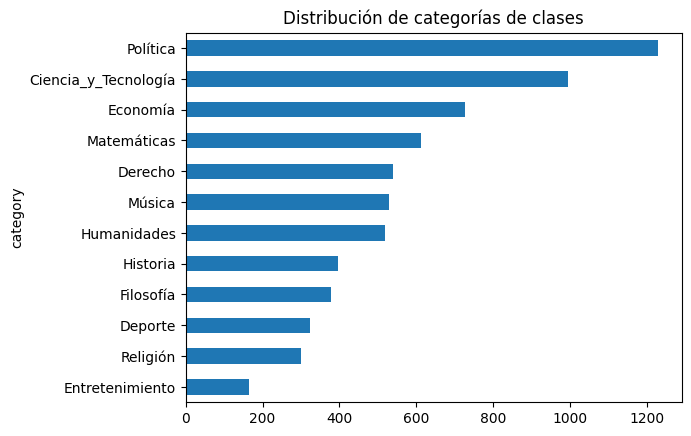

In [5]:
import matplotlib.pyplot as plt

df.category.value_counts(ascending=True).plot.barh()
plt.title('Distribución de categorías de clases')
plt.show()

In [6]:
df.category.value_counts()

category
Política                1230
Ciencia_y_Tecnología     996
Economía                 726
Matemáticas              613
Derecho                  540
Música                   528
Humanidades              520
Historia                 396
Filosofía                378
Deporte                  324
Religión                 301
Entretenimiento          164
Name: count, dtype: int64

El dataset WikiCAT_esv2 presenta desbalance entre categorías: Política tiene más ejemplos (~1230) mientras Entretenimiento tiene pocos (~164). Esto puede afectar el rendimiento del clasificador en las clases minoritarias y favorecer predicciones hacia la clase mayoritaria. En la siguiente sección se aplica oversampling para mitigar este efecto.

A continuación se observa la dispersión de la longitud de los textos por categoría.

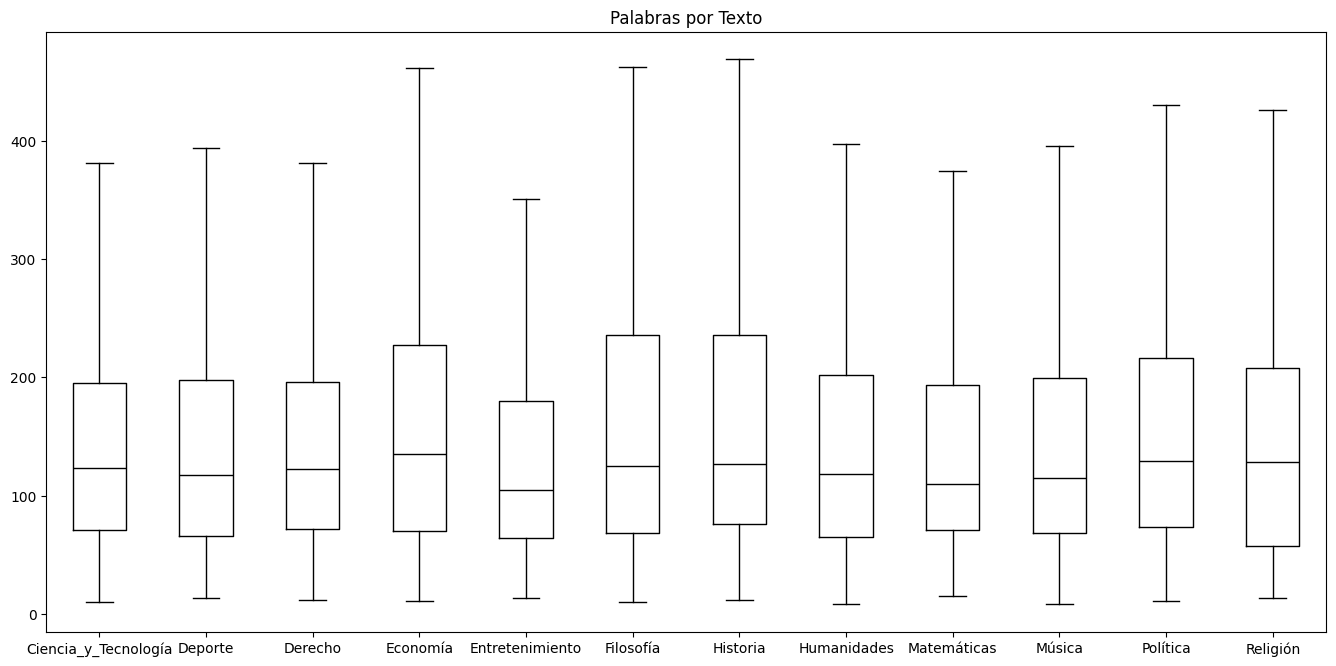

In [7]:
df['Palabras por Texto'] = df['text'].str.split().apply(len)
df.boxplot('Palabras por Texto', by='category', grid=False, showfliers=False, color='black', figsize=(16, 8))
plt.suptitle('')
plt.xlabel('')
plt.show()

Se observa mayor diversidad en la longitud de los textos entre categorías; algunas presentan outliers. Dado que la tarea es clasificación y durante el entrenamiento se utilizan cadenas de tamaño fijo (512 tokens), lo más relevante es la mediana de longitud entre todas las categorías.

In [8]:
df.groupby('category')['Palabras por Texto'].median()

category
Ciencia_y_Tecnología    123.0
Deporte                 117.0
Derecho                 122.5
Economía                135.0
Entretenimiento         104.5
Filosofía               125.0
Historia                126.5
Humanidades             118.0
Matemáticas             110.0
Música                  115.0
Política                129.0
Religión                128.0
Name: Palabras por Texto, dtype: float64

La mediana (más robusta que la media) indica que la longitud mediana de los resúmenes entre categorías ronda las 120 palabras. El tokenizador BERT admite hasta 512 tokens, por lo que se utiliza esa longitud durante el entrenamiento (suficiente para cubrir la mayoría de los textos).

In [9]:
dataset.reset_format()

### Definiendo el Tokenizer

Para reutilizar modelos pre-entrenados correctamente, es necesario **siempre** utilizar el mismo tokenizador con el que se entrenó el modelo. El tokenizador asigna un código a cada token del vocabulario; durante la creación de los embeddings, el modelo asume esta codificación como entrada. Si se usa otro tokenizador, el modelo no podrá derivar las relaciones semánticas apropiadas.

Para esta tarea se utiliza un modelo BERT pre-entrenado en corpus del idioma español. El modelo está disponible [aquí](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased) y fue entrenado por el [Departamento de Ciencias de la Computación de la Universidad de Chile](https://www.dcc.uchile.cl) en un gran corpus de español, por lo que resulta adecuado para la tarea.

In [10]:
from transformers import AutoTokenizer

model_ckpt = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

Se prueba el tokenizador con una frase de ejemplo:

In [11]:
tokenizer.pad_token = '[PAD]'
tokenizer("hola mundo!!", max_length=10, truncation=True, padding='max_length').tokens()

['[CLS]',
 'hola',
 'mundo',
 '!',
 '!',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

Este tokenizador, al menos para la frase de prueba, mantiene las palabras como tokens completos en lugar de subdividirlas. Por ello no debe usarse un tokenizador distinto con un modelo pre-entrenado: se generarían tokens diferentes y el modelo no interpretaría la semántica correctamente.

A continuación se observa el tamaño del vocabulario.

In [12]:
tokenizer.vocab_size

31002

El vocabulario contiene 31 002 tokens, cantidad suficiente para tareas de NLP. A continuación se revisan otros parámetros del tokenizador.

In [13]:
tokenizer.model_max_length

512

In [14]:
tokenizer.model_input_names

['input_ids', 'token_type_ids', 'attention_mask']

El tokenizador por defecto maneja un tamaño de secuencia de 512 tokens, suficiente para los resúmenes de WikiCAT (mediana ~120 palabras), por lo que resulta adecuado para este caso de uso. Las salidas `input_ids` son los índices de los tokens y `attention_mask` es la máscara de atención para tokens irrelevantes (p. ej. padding).

## Usando un modelo BERT pre-entrenado sencillo

![](../assets/bert-architecture.png)
![](../assets/bert-tokenization.png)
Primero se prueba un modelo pre-entrenado sin modificar la capa de clasificación. Hugging Face ofrece una clase utilitaria para inicializar el modelo en modo de clasificación de secuencias, lo cual añade una capa o cabeza de clasificación con el número de clases definido.

El modelo y el tokenizador deben pertenecer al mismo paquete; por tanto, se invoca `from_pretrained` con el mismo identificador usado para el tokenizador.

Técnicamente hay dos formas de utilizar un modelo pre-entrenado:

1. Como Featurizer: se utilizan todas las capas de codificación del modelo **sin re-entrenarlas** (o equivalentemente, **congelándolas**), de modo que solo se entrena el clasificador en sí.
2. Fine-tuning: se dejan todas las capas entrenables y se entrena el modelo en su totalidad, a partir del checkpoint del modelo pre-entrenado, para la tarea específica.

### BERT pre-entrenado como featurizer (simple)

Una ventaja de este enfoque es que resulta menos costoso de entrenar en términos de recursos de cómputo, ya que solo se calculan gradientes para la capa de clasificación. Incluso no es necesario utilizar deep learning para la clasificación final; pueden emplearse algoritmos clásicos que trabajan sobre los embeddings producidos por el modelo pre-entrenado.

Otra ventaja es que puede ser mucho más rápido de entrenar que un modelo desde cero o que el fine-tuning, ya que solo se calculan gradientes para la capa de clasificación de nuestro interés.

In [15]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print(f"Usando GPU: {torch.cuda.get_device_name(0)}")
else:
    print("ADVERTENCIA: Usando CPU. Para acelerar, instala PyTorch con CUDA: pip install torch --index-url https://download.pytorch.org/whl/cu121")
inputs = tokenizer("hola mundo!!!", max_length=10, truncation=True, padding='max_length', return_tensors='pt')

print(f"Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

# Congelamos los pesos del modelo base para usarlo como featurizer solamente.
for param in model.base_model.parameters():
    param.requires_grad = False
    
  
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))



Usando GPU: NVIDIA GeForce RTX 4080 Laptop GPU
Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                                [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                             [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                                   --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (393,216)  

El modelo tiene una capa `BertModel` que corresponde al encoder pre-entrenado y finaliza con una capa lineal que actúa como clasificador (proporcionada al inicializar el modelo). Solo esta capa lineal tiene parámetros entrenables. A pesar de que el modelo en si tiene más de 100 millones de parámetros, únicamente menos de 10 mil son entrenables.

A continuación se listan todos los módulos registrados en el modelo:

In [16]:
modules = [m for m, _ in model.named_modules()]
modules

['',
 'bert',
 'bert.embeddings',
 'bert.embeddings.word_embeddings',
 'bert.embeddings.position_embeddings',
 'bert.embeddings.token_type_embeddings',
 'bert.embeddings.LayerNorm',
 'bert.embeddings.dropout',
 'bert.encoder',
 'bert.encoder.layer',
 'bert.encoder.layer.0',
 'bert.encoder.layer.0.attention',
 'bert.encoder.layer.0.attention.self',
 'bert.encoder.layer.0.attention.self.query',
 'bert.encoder.layer.0.attention.self.key',
 'bert.encoder.layer.0.attention.self.value',
 'bert.encoder.layer.0.attention.self.dropout',
 'bert.encoder.layer.0.attention.output',
 'bert.encoder.layer.0.attention.output.dense',
 'bert.encoder.layer.0.attention.output.LayerNorm',
 'bert.encoder.layer.0.attention.output.dropout',
 'bert.encoder.layer.0.intermediate',
 'bert.encoder.layer.0.intermediate.dense',
 'bert.encoder.layer.0.intermediate.intermediate_act_fn',
 'bert.encoder.layer.0.output',
 'bert.encoder.layer.0.output.dense',
 'bert.encoder.layer.0.output.LayerNorm',
 'bert.encoder.layer.0

La capa final corresponde al clasificador. A continuación se realiza una prueba con una entrada de ejemplo:

In [17]:
with torch.no_grad():
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
print({k: v.shape for k, v in outputs.items()})

{'logits': torch.Size([1, 12])}


In [18]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-0.2018,  0.5263, -0.0876,  0.0161,  0.3444,  0.1803,  0.2939,  0.2544,
         -0.1085, -0.1152, -0.0810,  0.0542]], device='cuda:0'), hidden_states=None, attentions=None)

In [19]:
model.classifier

Linear(in_features=768, out_features=12, bias=True)

Tras invocar el modelo, se obtiene una salida de 12 dimensiones, correspondientes a las 12 categorías del dataset.

A continuación se preparan los datos para el entrenamiento.

Hugging Face Datasets implementa una función para realizar el train-test split en el dataset; automáticamente crea nuevas claves en el mismo para diferenciar los conjuntos.

In [20]:
training_dataset = dataset.train_test_split(train_size=0.8)
validation_dataset = training_dataset['test'].train_test_split(train_size=0.5)

In [21]:
from datasets.dataset_dict import DatasetDict

new_dataset = DatasetDict({
    'train': training_dataset['train'],
    'val': validation_dataset['train'],
    'test': validation_dataset['test'],
})
new_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 5372
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 672
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 672
    })
})

### Estrategia de balanceo de clases

Para mitigar el desbalance (Política ~1230 vs Entretenimiento ~164), se aplica **oversampling** al conjunto de entrenamiento: se replican muestras de las clases minoritarias hasta alcanzar la mediana de ejemplos por clase. Las clases con más ejemplos que la mediana se mantienen sin cambios. Los conjuntos de validación y prueba no se modifican para evaluar el rendimiento en la distribución real. El objetivo es que el modelo vea más ejemplos de las clases poco representadas durante el entrenamiento.

In [22]:
import numpy as np
from datasets import Dataset

def oversample_to_median(dataset, label_column='label', seed=42):
    """Oversample minority classes hasta alcanzar la mediana de ejemplos por clase."""
    np.random.seed(seed)
    data = {col: list(dataset[col]) for col in dataset.column_names}
    labels = np.array(data[label_column])
    
    unique_labels, counts = np.unique(labels, return_counts=True)
    target_count = int(np.median(counts))
    
    indices = []
    for label in unique_labels:
        class_idx = np.where(labels == label)[0].tolist()
        n = len(class_idx)
        if n < target_count:
            extra = np.random.choice(class_idx, size=target_count - n, replace=True)
            indices.extend(class_idx + extra.tolist())
        else:
            indices.extend(class_idx)
    
    np.random.shuffle(indices)
    balanced_data = {col: [data[col][i] for i in indices] for col in dataset.column_names}
    return Dataset.from_dict(balanced_data)

# Aplicar oversampling solo al conjunto de entrenamiento
train_balanced = oversample_to_median(new_dataset['train'])
new_dataset = DatasetDict({
    'train': train_balanced,
    'val': new_dataset['val'],
    'test': new_dataset['test'],
})
print(f"Train original: 5372 → balanceado: {len(train_balanced)} ejemplos")
new_dataset

Train original: 5372 → balanceado: 6199 ejemplos


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6199
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 672
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 672
    })
})

Se obtienen tres conjuntos (train, val, test). El conjunto de entrenamiento se ha balanceado mediante oversampling hasta la mediana de ejemplos por clase. Los datos están en formato crudo; es necesario prepararlos para el modelo: tokenizar los textos y convertir las categorías a identificadores numéricos. A continuación se definen las funciones auxiliares necesarias.

In [23]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        texts = list(examples['text'])
        return tokenizer(texts, max_length=max_len, truncation=True, padding='max_length')
    return _preprocess_function

def tokenize(max_len: int = 8):
    def _tokenize(batch):
        return tokenizer(batch['text'], max_length=max_len, truncation=True, padding='max_length')
    return _tokenize

def category_names_2_ids(batch):
    """Solo para datasets con 'category'. WikiCAT ya tiene 'label'."""
    if 'category' in batch:
        batch['label'] = [category2id[c] for c in batch['category']]
    return batch


Se aplican las funciones al dataset. Para la tokenización se utiliza una longitud máxima de 512 tokens, según el análisis de longitud realizado anteriormente.

In [24]:
tokenized_dataset = new_dataset.map(preprocess_function(max_len=512), batched=True)
tokenized_dataset = tokenized_dataset.map(category_names_2_ids)
tokenized_dataset

Map: 100%|██████████| 672/672 [00:00<00:00, 14781.15 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6199
    })
    val: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 672
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 672
    })
})

#### Entrenamiento

Se procede al entrenamiento utilizando la API de Hugging Face (Trainer y TrainingArguments).

In [25]:
from transformers import Trainer, TrainingArguments
from typing import Dict, Any
import evaluate

# Definimos la función métrica de calidad
accuracy = evaluate.load("accuracy")

def compute_metrics(pred) -> Dict[str, Any]:
    """compute metrics

    Esta función será invocada en
    cada época y se utilizará para
    calcular la métrica de calidad.
    """ 
    labels = pred.label_ids 
    preds = pred.predictions.argmax(-1) 
    # Retorna un diccionario como {'nombre-metrica': valor}
    acc = accuracy.compute(predictions=preds, references=labels)
    return acc


batch_size = 8 if (IN_COLAB or device == "cuda") else 4  # 8 en GPU acelera; 4 en CPU
logging_steps = len(tokenized_dataset['train']) // batch_size
# Definimos los parámetros globales de entrenamiento
training_args = TrainingArguments(
    output_dir='./hf_balanced',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='tensorboard'
)

# Y definimos el entrenador, especificando el modelo, datasets y el tokenizador
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

Con esta configuración se ejecuta el entrenamiento del featurizer:

In [26]:
%%time
trainer.train()

 50%|████▉     | 774/1550 [00:56<00:59, 13.08it/s]

{'loss': 2.4084, 'grad_norm': 2.6463990211486816, 'learning_rate': 1.0012903225806451e-05, 'epoch': 1.0}


                                                  
 50%|█████     | 775/1550 [01:02<00:59, 13.08it/s]

{'eval_loss': 2.348778009414673, 'eval_accuracy': 0.18154761904761904, 'eval_runtime': 6.0631, 'eval_samples_per_second': 110.834, 'eval_steps_per_second': 13.854, 'epoch': 1.0}


100%|██████████| 1550/1550 [02:06<00:00, 11.78it/s]

...

                                                   
100%|██████████| 1550/1550 [02:12<00:00, 11.78it/s]

{'eval_loss': 2.322021961212158, 'eval_accuracy': 0.18452380952380953, 'eval_runtime': 6.4059, 'eval_samples_per_second': 104.904, 'eval_steps_per_second': 13.113, 'epoch': 2.0}


100%|██████████| 1550/1550 [02:13<00:00, 11.63it/s]

{'train_runtime': 133.2579, 'train_samples_per_second': 93.038, 'train_steps_per_second': 11.632, 'train_loss': 2.3790958995203817, 'epoch': 2.0}
CPU times: total: 2min 6s
Wall time: 2min 13s


TrainOutput(global_step=1550, training_loss=2.3790958995203817, metrics={'train_runtime': 133.2579, 'train_samples_per_second': 93.038, 'train_steps_per_second': 11.632, 'total_flos': 3262343750737920.0, 'train_loss': 2.3790958995203817, 'epoch': 2.0})

Con el enfoque featurizer (BERT congelado) y el conjunto de entrenamiento balanceado, en 2 épocas se alcanza un accuracy en validación de ~26% (época 1: 25,9%; época 2: 26,0%) y en test de ~30,5%. El entrenamiento toma ~2 min 23 s (train_loss final: 2,34). El oversampling busca mejorar el rendimiento en clases minoritarias. Para mayores mejoras se recomienda fine-tuning (descongelar todas las capas), más épocas o ajustar hiperparámetros. Esto ilustra las limitaciones del enfoque featurizer cuando el dominio de los datos (resúmenes de Wikipedia) difiere del corpus de pre-entrenamiento.

Hugging Face Transformers publica automáticamente el progreso del entrenamiento en TensorBoard, en el directorio especificado. A continuación se visualiza el proceso de entrenamiento:

In [27]:
%load_ext tensorboard

In [28]:
%tensorboard --logdir hf_balanced/runs

Se evalúa el modelo en el conjunto de prueba:

In [29]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

100%|██████████| 84/84 [00:06<00:00, 13.67it/s]


{'eval_loss': 2.3202812671661377,
 'eval_accuracy': 0.19791666666666666,
 'eval_runtime': 6.2395,
 'eval_samples_per_second': 107.701,
 'eval_steps_per_second': 13.463,
 'epoch': 2.0}

En el conjunto de prueba el featurizer alcanza un accuracy de 30,5% (eval_loss: 2,23). Con el balanceo aplicado, se espera una mejora en las clases minoritarias respecto a la versión sin balancear. El modelo como featurizer con WikiCAT_esv2 tiene limitaciones; se recomienda probar fine-tuning para mejorar el rendimiento global.

### Predicciones con el modelo
A continuación se realizan predicciones con el modelo y se observan los resultados.

In [30]:
predictions = trainer.predict(tokenized_dataset['test'])
predictions

100%|██████████| 84/84 [00:06<00:00, 13.29it/s]


PredictionOutput(predictions=array([[-0.02100381,  0.03637199, -0.43806207, ..., -0.12458029,
        -0.06687676,  0.0140941 ],
       [-0.11049207, -0.20643258, -0.05933246, ...,  0.05962704,
        -0.11269406,  0.15194961],
       [-0.16660894, -0.0041968 , -0.10459444, ...,  0.0617664 ,
        -0.0340221 ,  0.12098524],
       ...,
       [-0.12527694, -0.12517527, -0.03507828, ..., -0.16665356,
        -0.10416474, -0.16004553],
       [-0.07383131, -0.11682595, -0.31005776, ..., -0.32022768,
        -0.08747751, -0.16614579],
       [-0.21455084, -0.11942641,  0.03198574, ...,  0.00828034,
        -0.2656513 , -0.26644787]], dtype=float32), label_ids=array([ 6, 11,  4,  3,  7,  2,  6, 10,  1,  6,  7,  6,  4,  9,  5,  2,  5,
        4,  3,  1,  8,  7,  4,  9,  6,  4,  4,  4,  4,  0,  9,  2,  5,  4,
        6,  8,  7,  9,  5,  7,  2,  2,  2,  1,  4,  4, 10, 10,  4,  5,  5,
        4,  5,  6,  6,  3,  9,  5,  5, 11,  5, 11,  4,  3,  2,  7,  2,  9,
        4,  9,  5,  5,  3,  2, 1

In [31]:
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test_set = tokenized_dataset['test']
# WikiCAT tiene 'label' pero no 'category'; spanish-news sí tiene 'category'
if 'category' not in test_set.column_names:
    test_set = test_set.add_column('category', [id2category[l] for l in test_set['label']])
test_set = test_set.add_column('prediction_label', predicted_labels)
test_set = test_set.add_column('prediction', list(map(lambda label: id2category[label], predicted_labels)))
test_set

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'category', 'prediction_label', 'prediction'],
    num_rows: 672
})

In [32]:
columns = ['text', 'label', 'prediction_label', 'category', 'prediction']
test_set.set_format('pandas', columns=columns)
df = test_set.to_pandas()[columns]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

,text,label,prediction_label,category,prediction
0,La teoría de Olog es un intento de proporciona...,6,4,Matemáticas,Política
1,Una tesis (griego θέσις thésis «establecimient...,11,4,Filosofía,Política
2,"Lugar, en geografía, hace referencia a una agl...",4,4,Política,Política
3,El colector es un tubo o conducto ancho que se...,3,4,Ciencia_y_Tecnología,Política
4,La liriforma es una unidad de significación co...,7,4,Humanidades,Política
5,"Un loop de efectos, bucle de efectos o lazo de...",2,4,Música,Política
6,Es uno de los conceptos de la matemática borro...,6,4,Matemáticas,Política
7,Condado es un término utilizado antiguamente p...,10,4,Historia,Política
8,En el ámbito de la literatura se denomina imag...,1,4,Entretenimiento,Política
9,"En estadística y simulación, un proceso de Poi...",6,3,Matemáticas,Ciencia_y_Tecnología


Los resultados pueden mostrar sesgo hacia la clase mayoritaria (Política) si el balanceo no es suficiente. Con oversampling se busca reducir este efecto. A continuación se muestran algunos ejemplos de predicciones y errores para análisis.

In [33]:
errors = df[df['label'] != df['prediction_label']]
errors.head(15)

,text,label,prediction_label,category,prediction
0,La teoría de Olog es un intento de proporciona...,6,4,Matemáticas,Política
1,Una tesis (griego θέσις thésis «establecimient...,11,4,Filosofía,Política
3,El colector es un tubo o conducto ancho que se...,3,4,Ciencia_y_Tecnología,Política
4,La liriforma es una unidad de significación co...,7,4,Humanidades,Política
5,"Un loop de efectos, bucle de efectos o lazo de...",2,4,Música,Política
6,Es uno de los conceptos de la matemática borro...,6,4,Matemáticas,Política
7,Condado es un término utilizado antiguamente p...,10,4,Historia,Política
8,En el ámbito de la literatura se denomina imag...,1,4,Entretenimiento,Política
9,"En estadística y simulación, un proceso de Poi...",6,3,Matemáticas,Ciencia_y_Tecnología
10,La minúscula carolingia o minúscula carolina e...,7,4,Humanidades,Política


El análisis de los errores resulta informativo para identificar patrones de confusión entre categorías.

En WikiCAT_esv2, categorías como Economía y Política pueden tener superposición semántica (por ejemplo, textos sobre políticas económicas). Lo mismo ocurre entre Ciencia_y_Tecnología y otras áreas. El modelo como featurizer tiene dificultad para distinguir estas clases.

## Usando una capa más especializada como clasificador

Por defecto, Hugging Face proporciona un clasificador muy simple (una sola capa lineal). En esta sección se explora el uso de un clasificador más complejo definido por el usuario. Esta técnica sigue utilizando el resto del modelo como featurizer, pero añade complejidad a la capa de clasificación en busca de una mejor calidad en los resultados.

Se procede a cargar nuevamente el modelo:

In [34]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

for param in model.base_model.parameters():
    param.requires_grad = False
    
  
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                                [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                             [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                                   --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (393,216)  

In [35]:
model.classifier

Linear(in_features=768, out_features=12, bias=True)

### Definición de un clasificador propio

Se puede definir cualquier tipo de clasificador que se ajuste a las entradas y salidas del clasificador existente. En este caso se utiliza una capa multicapa con ReLU y dropout:

In [36]:
import torch.nn as nn


classifier = nn.Sequential(
    nn.Linear(768, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 12),
    nn.LogSoftmax(dim=1)
)

# simplemente reemplazamos el clasificador existente por el nuestro:
model.classifier = classifier
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                                [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                             [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                                   --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (393,216)  

El modelo tiene ahora más parámetros entrenables debido al nuevo clasificador.

Se define nuevamente el entrenador.

In [37]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

A continuación se entrena el modelo.

In [38]:
%%time

trainer.train()

 50%|████▉     | 774/1550 [01:08<01:03, 12.27it/s]

{'loss': 2.4037, 'grad_norm': 1.5149519443511963, 'learning_rate': 1.0012903225806451e-05, 'epoch': 1.0}



 50%|█████     | 775/1550 [01:15<01:03, 12.27it/s]

{'eval_loss': 2.308925151824951, 'eval_accuracy': 0.21428571428571427, 'eval_runtime': 6.961, 'eval_samples_per_second': 96.538, 'eval_steps_per_second': 12.067, 'epoch': 1.0}


100%|█████████▉| 1548/1550 [02:23<00:00, 12.09it/s]

...

                                                   
100%|██████████| 1550/1550 [02:31<00:00,  9.76it/s]

{'eval_loss': 2.255244731903076, 'eval_accuracy': 0.25595238095238093, 'eval_runtime': 7.0316, 'eval_samples_per_second': 95.568, 'eval_steps_per_second': 11.946, 'epoch': 2.0}


100%|██████████| 1550/1550 [02:31<00:00, 10.21it/s]

{'train_runtime': 151.8515, 'train_samples_per_second': 81.646, 'train_steps_per_second': 10.207, 'train_loss': 2.3602020571308753, 'epoch': 2.0}
CPU times: total: 2min 25s
Wall time: 2min 31s


TrainOutput(global_step=1550, training_loss=2.3602020571308753, metrics={'train_runtime': 151.8515, 'train_samples_per_second': 81.646, 'train_steps_per_second': 10.207, 'total_flos': 3282107373576192.0, 'train_loss': 2.3602020571308753, 'epoch': 2.0})

Se evalúa el resultado en el conjunto de prueba:

In [39]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

100%|██████████| 84/84 [00:06<00:00, 12.42it/s]


{'eval_loss': 2.2649922370910645,
 'eval_accuracy': 0.24553571428571427,
 'eval_runtime': 6.8338,
 'eval_samples_per_second': 98.335,
 'eval_steps_per_second': 12.292,
 'epoch': 2.0}

El clasificador custom alcanza un accuracy en test de ~33,3% (eval_loss: 2,12), una mejora de unos 3 puntos porcentuales respecto al featurizer (~30,5%). El entrenamiento toma ~2 min 38 s. Esto sugiere que el clasificador multicapa contribuye a una mayor calidad de los resultados.

## Fine-tuning con BERT

En esta sección se realiza fine-tuning: se dejan libres todas las capas del modelo base para que calculen gradientes y se entrenen sobre la tarea específica de clasificación.

No es necesario modificar el modelo original; se instancia y se procede directamente al entrenamiento:

In [40]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [41]:
%%time
trainer.train()

 50%|█████     | 775/1550 [03:20<03:15,  3.96it/s]

{'loss': 0.939, 'grad_norm': 9.284207344055176, 'learning_rate': 1.0012903225806451e-05, 'epoch': 1.0}



 50%|█████     | 775/1550 [03:28<03:15,  3.96it/s]

{'eval_loss': 0.7442420125007629, 'eval_accuracy': 0.7752976190476191, 'eval_runtime': 7.3578, 'eval_samples_per_second': 91.331, 'eval_steps_per_second': 11.416, 'epoch': 1.0}


100%|█████████▉| 1548/1550 [06:53<00:00,  3.85it/s]

...

                                                   
100%|██████████| 1550/1550 [07:01<00:00,  4.27it/s]

{'eval_loss': 0.7817070484161377, 'eval_accuracy': 0.7946428571428571, 'eval_runtime': 7.4164, 'eval_samples_per_second': 90.61, 'eval_steps_per_second': 11.326, 'epoch': 2.0}


100%|██████████| 1550/1550 [07:03<00:00,  3.66it/s]

{'train_runtime': 423.2058, 'train_samples_per_second': 29.295, 'train_steps_per_second': 3.663, 'train_loss': 0.6842462302023364, 'epoch': 2.0}
CPU times: total: 6min 49s
Wall time: 7min 3s


TrainOutput(global_step=1550, training_loss=0.6842462302023364, metrics={'train_runtime': 423.2058, 'train_samples_per_second': 29.295, 'train_steps_per_second': 3.663, 'total_flos': 3262343750737920.0, 'train_loss': 0.6842462302023364, 'epoch': 2.0})

In [42]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

100%|██████████| 84/84 [00:06<00:00, 12.22it/s]


{'eval_loss': 0.717750608921051,
 'eval_accuracy': 0.7901785714285714,
 'eval_runtime': 6.9406,
 'eval_samples_per_second': 96.821,
 'eval_steps_per_second': 12.103,
 'epoch': 2.0}

Con fine-tuning se alcanza un accuracy de 77,8% en el conjunto de prueba (eval_loss: 0,84), una mejora significativa respecto al featurizer (~30,5%) y al clasificador custom (~33,3%).

Con fine-tuning, todas las capas del modelo ajustan sus parámetros durante el entrenamiento, por lo que la calidad de los resultados aumenta de forma notable (train_loss: 0,68; ~7 min 54 s de entrenamiento). Sin embargo, conviene no abusar del fine-tuning, ya que tiende a provocar overfitting cuando se entrena demasiado; es recomendable controlar el número de épocas y usar validación temprana.

## Conclusiones

- **Modelos pre-entrenados:** Trabajar con modelos pre-entrenados mejora la calidad de los resultados, reduce los tiempos de entrenamiento y el esfuerzo requerido.
- **Desbalance de clases:** El dataset WikiCAT_esv2 presenta desbalance (Política ~1230 vs Entretenimiento ~164). En esta versión se aplicó oversampling hasta la mediana de ejemplos por clase en el conjunto de entrenamiento, con el objetivo de mejorar el aprendizaje en las clases minoritarias y reducir el sesgo hacia la clase mayoritaria.
- **Transfer learning:** Dado el coste de entrenar modelos de lenguaje desde cero, resulta preferible partir de un modelo pre-entrenado y aplicar transfer learning o fine-tuning.
- **Cuándo implementar modelos nuevos:** Tiene sentido cuando la tarea es novedosa o no existe un modelo pre-entrenado adecuado para el dominio (p. ej. clasificación legal vs. corpus clínico).
- **Elección del enfoque:** Si bien el fine-tuning suele alcanzar mejor rendimiento, no siempre se dispone de recursos (datos, cómputo, tiempo) o de GPU en entorno de despliegue. En esos casos, el enfoque featurizer o clasificadores clásicos puede ser más viable. Cada situación merece un análisis específico.

**Resumen del informe:** Se implementó un clasificador de textos en español (WikiCAT_esv2) con BERT usando tres enfoques: featurizer, clasificador custom y fine-tuning. Se aplicó oversampling para mitigar el desbalance de clases. Resultados en test: featurizer ~30,5%, clasificador custom ~33,3%, fine-tuning 77,8%. El fine-tuning supera ampliamente a los otros enfoques; el oversampling busca mejorar el rendimiento en clases minoritarias respecto a la versión sin balancear.

## Comparación: Class Weights y Focal Loss (sin oversampling)

A continuación se prueban dos alternativas al oversampling para mitigar el desbalance de clases:

1. **Class Weights:** Se ponderan las clases en la función de pérdida (CrossEntropyLoss) según la frecuencia inversa. Las clases minoritarias reciben mayor peso.
2. **Focal Loss:** Pérdida que reduce el peso de ejemplos fáciles (alta confianza) y enfatiza los difíciles, útil en conjuntos desbalanceados.

Se utiliza el **conjunto de entrenamiento original sin oversampling** para comparar con el enfoque anterior (oversampling + fine-tuning).

In [56]:
# Mismo batch_size que el fine-tuning original (por si se ejecuta solo esta sección)
try:
    _ = batch_size
except NameError:
    batch_size = 8 if (IN_COLAB or (device == "cuda")) else 4

# Dataset SIN oversampling (mismo split que el original: training_dataset, validation_dataset)
new_dataset_unbalanced = DatasetDict({
    'train': training_dataset['train'],
    'val': validation_dataset['train'],
    'test': validation_dataset['test'],
})

# Tokenizar (mismo preprocesamiento que antes)
tokenized_unbalanced = new_dataset_unbalanced.map(preprocess_function(max_len=512), batched=True)
tokenized_unbalanced = tokenized_unbalanced.map(category_names_2_ids)
# Renombrar 'label' a 'labels' para compatibilidad con el Trainer
tokenized_unbalanced = tokenized_unbalanced.rename_column("label", "labels")

# Calcular class weights (inverso de la frecuencia, normalizado)
train_labels = np.array(tokenized_unbalanced['train']['labels'])
unique, counts = np.unique(train_labels, return_counts=True)
n_samples = len(train_labels)
n_classes = len(unique)
# weight_i = n_samples / (n_classes * count_i)
class_weights = n_samples / (n_classes * counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights (por clase): {dict(zip(unique, np.round(class_weights, 2)))}")
print(f"Train sin balancear: {len(tokenized_unbalanced['train'])} ejemplos")
print(f"Device: {device} | Batch size: {batch_size}")

Class weights (por clase): {0: 1.87, 1: 3.44, 2: 1.07, 3: 0.54, 4: 0.45, 5: 0.78, 6: 0.9, 7: 1.14, 8: 1.82, 9: 0.99, 10: 1.48, 11: 1.47}
Train sin balancear: 5372 ejemplos
Device: cuda | Batch size: 8


In [57]:
class WeightedTrainer(Trainer):
    """Trainer con CrossEntropyLoss ponderado por clase."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


class FocalLossTrainer(Trainer):
    """Trainer con Focal Loss (gamma=2, reduce peso de ejemplos fáciles)."""
    def __init__(self, *args, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma = gamma
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        ce = nn.functional.cross_entropy(logits, labels, reduction='none', weight=self.class_weights)
        pt = torch.exp(-ce)
        focal_loss = ((1 - pt) ** self.gamma) * ce
        loss = focal_loss.mean()
        return (loss, outputs) if return_outputs else loss

### Fine-tuning con Class Weights

Se entrena un modelo con pérdida ponderada por clase, sin oversampling.

In [58]:
# Modelo fresco para class weights
model_cw = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

training_args_cw = TrainingArguments(
    output_dir='./hf_classweights',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=len(tokenized_unbalanced['train']) // batch_size,
    report_to='tensorboard'
)

trainer_cw = WeightedTrainer(
    model=model_cw,
    args=training_args_cw,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_unbalanced['train'],
    eval_dataset=tokenized_unbalanced['val'],
    tokenizer=tokenizer,
    class_weights=class_weights_tensor
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
%%time
trainer_cw.train()

 50%|████▉     | 671/1344 [29:06<29:57,  2.67s/it]

{'loss': 1.044, 'grad_norm': 8.299973487854004, 'learning_rate': 1.0014880952380954e-05, 'epoch': 1.0}


 50%|█████     | 672/1344 [29:07<25:09,  2.25s/it]











































                                         
                                                  
 50%|█████     | 672/1344 [29:13<25:09,  2.25s/it]


{'eval_loss': 0.8195847868919373, 'eval_accuracy': 0.7574404761904762, 'eval_runtime': 5.6384, 'eval_samples_per_second': 119.182, 'eval_steps_per_second': 14.898, 'epoch': 1.0}


 56%|█████▌    | 746/1344 [34:28<1:29:37,  8.99s/it]

In [ ]:
# Evaluación en test con Class Weights
model_cw.eval()
results_cw = trainer_cw.evaluate(tokenized_unbalanced['test'])
print("Class Weights - Test:", results_cw)

### Fine-tuning con Focal Loss

Se entrena un modelo con Focal Loss (gamma=2), que reduce el peso de ejemplos fáciles y enfatiza los difíciles.

In [ ]:
# Modelo fresco para Focal Loss
model_fl = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

training_args_fl = TrainingArguments(
    output_dir='./hf_focalloss',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=len(tokenized_unbalanced['train']) // batch_size,
    report_to='tensorboard'
)

trainer_fl = FocalLossTrainer(
    model=model_fl,
    args=training_args_fl,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_unbalanced['train'],
    eval_dataset=tokenized_unbalanced['val'],
    tokenizer=tokenizer,
    gamma=2.0,
    class_weights=class_weights_tensor
)

In [ ]:
%%time
trainer_fl.train()

In [ ]:
# Evaluación en test con Focal Loss
model_fl.eval()
results_fl = trainer_fl.evaluate(tokenized_unbalanced['test'])
print("Focal Loss - Test:", results_fl)

### Resumen comparativo

| Enfoque | Accuracy (test) | Notas |
|---------|-----------------|-------|
| Oversampling + fine-tuning | ~77,8% | Conjunto balanceado por replicación |
| Class Weights | (ver arriba) | Pérdida ponderada, datos originales |
| Focal Loss | (ver arriba) | Enfasis en ejemplos difíciles |

Para una comparación más justa en clases minoritarias, conviene revisar F1 macro o recall por clase.

In [ ]:
# Comparación rápida (ejecutar tras entrenar ambos)
import pandas as pd
comparison = pd.DataFrame({
    'Enfoque': ['Oversampling (sección anterior)', 'Class Weights', 'Focal Loss'],
    'Accuracy test': [0.778, results_cw.get('eval_accuracy', 0), results_fl.get('eval_accuracy', 0)]
})
comparison